In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
torch.manual_seed(0)
np.random.seed(0)


## Operator tutorial: nn.Conv1d

In [2]:

x = torch.randn(1,3,10) # Batch size 1, Channels 3, Length 10
# Pytorch Conv1D expects:
# input:  (batch, channels, length)
# conv.weight: (out_channels, in_channels, kernel_size)
# output: (batch, out_channels, length_out)

# Use kernel_size//2 for padding to maintain the same length after convolution

conv1d = nn.Conv1d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=2)
output = conv1d(x)
print(f"input shape: {x.shape}\nweight shape: {conv1d.weight.shape}\noutput shape: {output.shape}")

input shape: torch.Size([1, 3, 10])
weight shape: torch.Size([6, 3, 5])
output shape: torch.Size([1, 6, 10])


## Operator tutorial: nn.MaxPool1d

MaxPool1d downsamples your length dimension using the max operator

In [3]:
x = torch.tensor([[[-1, 2, 23, 4, -5, 0, 0, 8]]], dtype=torch.float32)  # Shape (1, 1, 8)
maxpool1d = nn.MaxPool1d(2)  # Kernel size 2
output = maxpool1d(x)
print(f"input: {x}\noutput after MaxPool1d: {output}")

input: tensor([[[-1.,  2., 23.,  4., -5.,  0.,  0.,  8.]]])
output after MaxPool1d: tensor([[[ 2., 23.,  0.,  8.]]])


In [4]:
!pip install datasets

In [5]:
from datasets import load_dataset
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F

ds = load_dataset("ylecun/mnist")

print(ds)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})


In [6]:
import numpy as np
import torch
from torch.utils.data import Dataset

class MNIST1D(Dataset):
    def __init__(self, hf_split):
        self.data = hf_split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img = np.array(item["image"], dtype=np.float32) / 255.0   # shape (28,28)

        img = torch.tensor(img).float()
        img = img.view(1, -1)            # 1 x 784 for Conv1d

        label = torch.tensor(item["label"], dtype=torch.long)
        return img, label

train_ds = MNIST1D(ds["train"])
test_ds = MNIST1D(ds["test"])


Image shape: torch.Size([1, 784]), Label: 5


Text(0.5, 1.0, 'Label: 5')

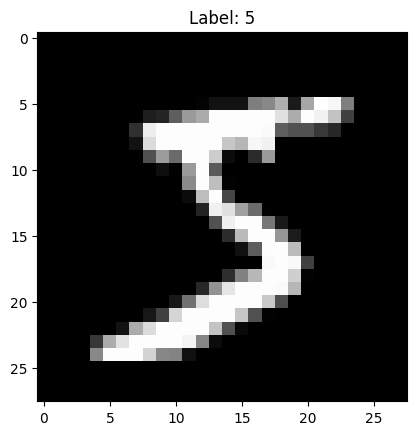

In [7]:
x,y = train_ds[0]
print(f"Image shape: {x.shape}, Label: {y}")
plt.imshow(x.view(28,28), cmap='gray')
plt.title(f"Label: {y.item()}")

In [12]:
import torch.nn as nn

# Build a 1D CNN for MNIST classification
# Your input shape is (B, 1, 784)
# Use series of conv1d, ReLU, MaxPool1d layers to downsample the input
# Then use flatten followed by a fully connected layer to output 10 logits

# Example Shape Flow : (B,1,784) →  (B,16,784) →  (B,32,784) →  (B,32,392) →  (B,64,196) → (B,64,98) →  (B, 64*98) → FC → (B,10)

class MNIST1DCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.MaxPool1d(kernel_size=2, stride=2) # Added this layer to match the example shape flow (B,64,98)
        )
        self.fc = nn.Linear(64*98, 10) # Define the input size for the fully connected layer

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1) # Flatten
        return self.fc(x)

    def collect_downsample_features(self, x):
        features = []
        for layer in self.net:
            x = layer(x)
            if isinstance(layer, nn.MaxPool1d):
                features.append(x)
        return features

model = MNIST1DCNN()
sum(p.numel() for p in model.parameters())

75722

In [13]:
import torch.optim as optim

#TODO: Set your hyperparameters
LR = 0.001
BATCH_SIZE = 128
WEIGHT_DECAY = 0.0001


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)
for epoch in range(5):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}: train loss = {total_loss / len(train_loader):.4f}")

Epoch 1: train loss = 0.3109
Epoch 2: train loss = 0.1332
Epoch 3: train loss = 0.1110
Epoch 4: train loss = 0.0967
Epoch 5: train loss = 0.0858


In [14]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        predicted = pred.argmax(dim=1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

print("Test accuracy:", correct / total)
# Get accuracy > 0.95

Test accuracy: 0.9717


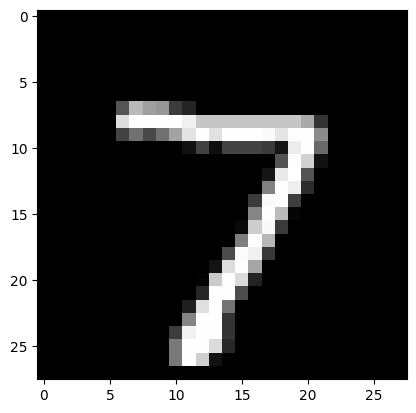

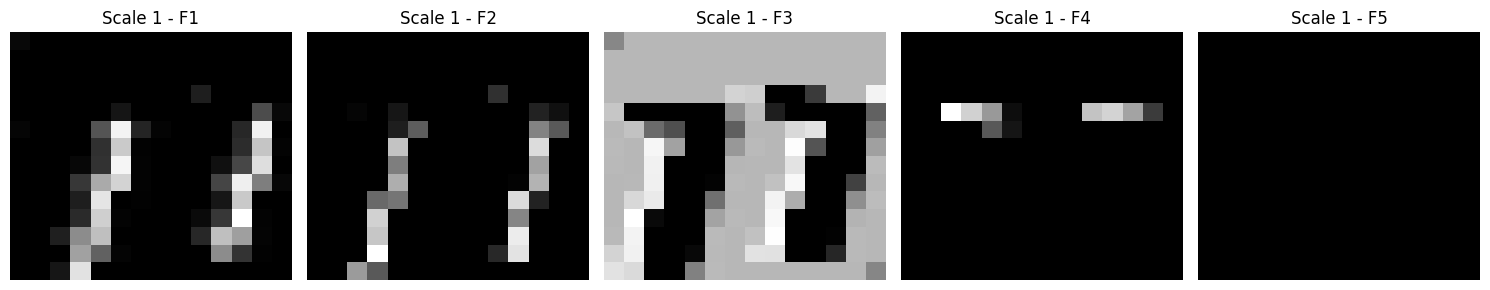

In [15]:
import matplotlib.pyplot as plt

MAX_DISPLAY_PER_SCALE = 5
x, y = test_ds[0]
x = x.to(device)
plt.imshow(x.view(28,28).cpu(), cmap='gray')
with torch.no_grad():
    # acts = model.net[0](x.unsqueeze(0))   # first conv layer output
    features = model.collect_downsample_features(x.unsqueeze(0))
    features = features[1::2] #Keep even max pooled features
    NUM_SCALES = len(features)
    # plot all feature maps
    plt.figure(figsize=(15, 3 * NUM_SCALES))
    for i in range(NUM_SCALES):
        for j in range(min(MAX_DISPLAY_PER_SCALE, features[i].shape[1])):
            plt_idx = i * MAX_DISPLAY_PER_SCALE + j + 1
            reshape_size = int(features[i].shape[2]**0.5)
            plt.subplot(NUM_SCALES, MAX_DISPLAY_PER_SCALE, plt_idx)
            plt.imshow(features[i][0, j, :].cpu().numpy().reshape(reshape_size, reshape_size), aspect='auto', cmap='gray')
            plt.title(f"Scale {i+1} - F{j+1}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()